# Facial Detection

- This notebook contains code to carry out facial detection & cropping required for gender & skin-tone labelling.

Metrics:
- Average Precision @ IOU 0.5 (All Faces)
- Mean Average Precision @ IOU 0.5 - 0.95 (COCO Style) (All Faces)
- Average Precision @ IOU 0.5 (Small / Medium / Large Faces)
- Precision-Recall Curve @ IOU 0.5 (All Faces)

<!-- -> https://claude.ai/chat/45762296-64fc-4701-8840-f81a3eb24466 -->

In [2]:
import os
import cv2
import numpy as np
from pathlib import Path
from typing import List, Tuple
import time

In [3]:
# =============================================================================
# SHARED UTILITIES
# =============================================================================

def crop_face(image: np.ndarray, bbox: Tuple[int, int, int, int], padding: int = 20) -> np.ndarray:
    """Crop face from image with padding"""
    x1, y1, x2, y2 = bbox
    h, w = image.shape[:2]
    
    # Add padding
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(w, x2 + padding)
    y2 = min(h, y2 + padding)
    
    return image[y1:y2, x1:x2]

def save_cropped_faces(image: np.ndarray, boxes: List[Tuple[int, int, int, int]], 
                       image_name: str, output_dir: Path, padding: int = 20) -> int:
    """Save all detected faces from an image"""
    for face_idx, bbox in enumerate(boxes, 1):
        face_crop = crop_face(image, bbox, padding)
        output_path = output_dir / f"{image_name}-face-{face_idx}.jpg"
        cv2.imwrite(str(output_path), face_crop)
    
    return len(boxes)

def collect_image_files(input_dir: str, extensions: List[str] = ['.jpg', '.jpeg', '.png']) -> List[str]:
    """Collect all image files from directory"""
    input_path = Path(input_dir)
    image_files = []
    
    for ext in extensions:
        image_files.extend(input_path.glob(f"*{ext}"))
    
    return [str(f) for f in image_files]

def print_stats(detector_name: str, stats: dict) -> None:
    """Print processing statistics"""
    print("\n" + "="*50)
    print(f"Detector: {detector_name}")
    print(f"Total images processed: {stats['total_images']}")
    print(f"Images with faces: {stats['images_with_faces']}")
    print(f"Total faces detected: {stats['total_faces']}")
    print(f"Average faces per image: {stats['total_faces'] / max(1, stats['total_images']):.2f}")
    print(f"Processing time: {stats['processing_time']:.2f}s")
    print(f"Average time per image: {stats['processing_time'] / max(1, stats['total_images']):.3f}s")
    print("="*50 + "\n")

## Retina Face

Link: https://github.com/serengil/retinaface

In [2]:
import os
import cv2
import numpy as np
from pathlib import Path
from typing import List, Tuple
import time

def process_with_retinaface(input_dir: str, output_dir: str, batch_size: int = 8, confidence_threshold: float = 0.5, padding: int = 20):
    """Process images with RetinaFace detector"""
    try:
        from retinaface import RetinaFace
    except ImportError:
        print("RetinaFace not installed. Run: pip install retinaface-pytorch")
        return None
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    image_files = collect_image_files(input_dir)
    total_images = len(image_files)
    
    if total_images == 0:
        print(f"No images found in {input_dir}")
        return None
    
    stats = {
        'total_images': 0,
        'total_faces': 0,
        'images_with_faces': 0,
        'processing_time': 0
    }
    
    print(f"Processing {total_images} images with RetinaFace...")
    
    for i in range(0, total_images, batch_size):
        batch_files = image_files[i:i + batch_size]
        
        for img_path in batch_files:
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Could not read {img_path}")
                continue
            
            # RetinaFace expects RGB
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            start_time = time.time()
            faces = RetinaFace.detect_faces(rgb_image)
            stats['processing_time'] += time.time() - start_time
            
            boxes = []
            if isinstance(faces, dict):
                for key, face_data in faces.items():
                    if face_data['score'] >= confidence_threshold:
                        box = face_data['facial_area']
                        boxes.append((box[0], box[1], box[2], box[3]))
            
            image_name = Path(img_path).stem
            face_count = save_cropped_faces(image, boxes, image_name, output_path, padding)
            
            stats['total_images'] += 1
            stats['total_faces'] += face_count
            if face_count > 0:
                stats['images_with_faces'] += 1
        
        processed = min(i + batch_size, total_images)
        print(f"Progress: {processed}/{total_images} images processed", end='\r')
    
    print()
    print_stats("RetinaFace", stats)
    return stats

In [ ]:
# Configuration
INPUT_DIR = r"ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images"
OUTPUT_BASE_DIR = r"DatasetAnnotation\FacialDetection\RetinaFace"
BATCH_SIZE = 8
CONFIDENCE_THRESHOLD = 0.5
PADDING = 20
model_path = r"DatasetAnnotation\yolov12l-face.pt"

process_with_retinaface(INPUT_DIR, OUTPUT_BASE_DIR, BATCH_SIZE, CONFIDENCE_THRESHOLD, PADDING)

Processing 10000 images with RetinaFace...


## SCRFD

Link: https://github.com/deepinsight/insightface/tree/master

In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path
from typing import List, Tuple
import time

def process_with_scrfd(input_dir: str, output_dir: str, batch_size: int = 8, confidence_threshold: float = 0.5, padding: int = 20):
    """Process images with SCRFD detector from InsightFace"""
    try:
        from insightface.app import FaceAnalysis
    except ImportError:
        print("InsightFace not installed. Run: pip install insightface onnxruntime")
        return None
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Initialize detector
    app = FaceAnalysis(allowed_modules=['detection'])
    app.prepare(ctx_id=0, det_thresh=confidence_threshold)
    
    image_files = collect_image_files(input_dir)
    total_images = len(image_files)
    
    if total_images == 0:
        print(f"No images found in {input_dir}")
        return None
    
    stats = {
        'total_images': 0,
        'total_faces': 0,
        'images_with_faces': 0,
        'processing_time': 0
    }
    
    print(f"Processing {total_images} images with SCRFD...")
    
    for i in range(0, total_images, batch_size):
        batch_files = image_files[i:i + batch_size]
        
        for img_path in batch_files:
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Could not read {img_path}")
                continue
            
            start_time = time.time()
            faces = app.get(image)
            stats['processing_time'] += time.time() - start_time
            
            boxes = []
            for face in faces:
                bbox = face.bbox.astype(int)
                boxes.append((bbox[0], bbox[1], bbox[2], bbox[3]))
            
            image_name = Path(img_path).stem
            face_count = save_cropped_faces(image, boxes, image_name, output_path, padding)
            
            stats['total_images'] += 1
            stats['total_faces'] += face_count
            if face_count > 0:
                stats['images_with_faces'] += 1
        
        processed = min(i + batch_size, total_images)
        print(f"Progress: {processed}/{total_images} images processed", end='\r')
    
    print()
    print_stats("SCRFD", stats)
    return stats

In [ ]:
# Configuration
INPUT_DIR = r"ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images"
OUTPUT_BASE_DIR = r"DatasetAnnotation\FacialDetection\SCRFD"
BATCH_SIZE = 8
CONFIDENCE_THRESHOLD = 0.5
PADDING = 20

process_with_scrfd(INPUT_DIR, OUTPUT_BASE_DIR, BATCH_SIZE, CONFIDENCE_THRESHOLD, PADDING)

## YOLO-face

Link: https://github.com/YapaLab/yolo-face

In [43]:
import os
import cv2
import numpy as np
from pathlib import Path
from typing import List, Tuple
import time

def process_with_yolo_face(input_dir: str, output_dir: str, model_path: str, batch_size: int = 8, confidence_threshold: float = 0.5, padding: int = 20):
    """Process images with YOLOv8-Face detector"""
    try:
        from ultralytics import YOLO
    except ImportError:
        print("Ultralytics not installed. Run: pip install ultralytics")
        return None
    
    if not os.path.exists(model_path):
        print(f"Model not found: {model_path}")
        return None
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Load model
    model = YOLO(model_path)
    
    image_files = collect_image_files(input_dir)
    total_images = len(image_files)
    
    if total_images == 0:
        print(f"No images found in {input_dir}")
        return None
    
    stats = {
        'total_images': 0,
        'total_faces': 0,
        'images_with_faces': 0,
        'processing_time': 0
    }
    
    print(f"Processing {total_images} images with YOLOv8-Face...")
    
    for i in range(0, total_images, batch_size):
        batch_files = image_files[i:i + batch_size]
        
        # Read batch images
        batch_images = []
        valid_files = []
        for img_path in batch_files:
            img = cv2.imread(img_path)
            if img is not None:
                batch_images.append(img)
                valid_files.append(img_path)
        
        if not batch_images:
            continue
        
        # Process batch
        start_time = time.time()
        results = model(batch_images, conf=confidence_threshold, verbose=False)
        stats['processing_time'] += time.time() - start_time
        
        # Save results
        for img, result, img_path in zip(batch_images, results, valid_files):
            boxes = []
            if result.boxes is not None:
                for box in result.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    boxes.append((int(x1), int(y1), int(x2), int(y2)))
            
            image_name = Path(img_path).stem
            face_count = save_cropped_faces(img, boxes, image_name, output_path, padding)
            
            stats['total_images'] += 1
            stats['total_faces'] += face_count
            if face_count > 0:
                stats['images_with_faces'] += 1
        
        processed = min(i + batch_size, total_images)
        print(f"Progress: {processed}/{total_images} images processed", end='\r')
    
    print()
    print_stats("YOLO-Face", stats)
    return stats

In [ ]:
# Configuration
INPUT_DIR = r"ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images"
OUTPUT_BASE_DIR = r"DatasetAnnotation\FacialDetection\Yolo"
BATCH_SIZE = 8
CONFIDENCE_THRESHOLD = 0.5
PADDING = 20
model_path = r"DatasetAnnotation\yolov12l-face.pt"

process_with_yolo_face(INPUT_DIR, OUTPUT_BASE_DIR, model_path, BATCH_SIZE, CONFIDENCE_THRESHOLD, PADDING)

## MediaPipe Face Detection

Link: https://mediapipe.readthedocs.io/en/latest/solutions/face_detection.html

In [16]:
import os
import cv2
import numpy as np
from pathlib import Path
from typing import List, Tuple
import time

def process_with_mediapipe(input_dir: str, output_dir: str, batch_size: int = 8, confidence_threshold: float = 0.5, padding: int = 20):
    """Process images with MediaPipe Face Detection"""
    try:
        import mediapipe as mp
    except ImportError:
        print("MediaPipe not installed. Run: pip install mediapipe")
        return None
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Initialize detector
    mp_face_detection = mp.solutions.face_detection
    detector = mp_face_detection.FaceDetection(
        model_selection=1,  # 1 for full range, 0 for short range
        min_detection_confidence=confidence_threshold
    )
    
    image_files = collect_image_files(input_dir)
    total_images = len(image_files)
    
    if total_images == 0:
        print(f"No images found in {input_dir}")
        return None
    
    stats = {
        'total_images': 0,
        'total_faces': 0,
        'images_with_faces': 0,
        'processing_time': 0
    }
    
    print(f"Processing {total_images} images with MediaPipe...")
    
    for i in range(0, total_images, batch_size):
        batch_files = image_files[i:i + batch_size]
        
        for img_path in batch_files:
            image = cv2.imread(img_path)
            if image is None:
                print(f"Warning: Could not read {img_path}")
                continue
            
            # MediaPipe expects RGB
            rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            start_time = time.time()
            results = detector.process(rgb_image)
            stats['processing_time'] += time.time() - start_time
            
            boxes = []
            if results.detections:
                h, w, _ = image.shape
                for detection in results.detections:
                    bbox = detection.location_data.relative_bounding_box
                    x1 = int(bbox.xmin * w)
                    y1 = int(bbox.ymin * h)
                    x2 = int((bbox.xmin + bbox.width) * w)
                    y2 = int((bbox.ymin + bbox.height) * h)
                    boxes.append((x1, y1, x2, y2))
            
            image_name = Path(img_path).stem
            face_count = save_cropped_faces(image, boxes, image_name, output_path, padding)
            
            stats['total_images'] += 1
            stats['total_faces'] += face_count
            if face_count > 0:
                stats['images_with_faces'] += 1
        
        processed = min(i + batch_size, total_images)
        print(f"Progress: {processed}/{total_images} images processed", end='\r')
    
    print()
    print_stats("MediaPipe", stats)
    return stats

In [ ]:
# Configuration
INPUT_DIR = r"ImageCaptioningEvaluationDatasets\LAION-5B-10k\LAION-5B-10k-images"
OUTPUT_BASE_DIR = r"DatasetAnnotation\FacialDetection\MediaPipe"
BATCH_SIZE = 8
CONFIDENCE_THRESHOLD = 0.5
PADDING = 20

process_with_mediapipe(INPUT_DIR, OUTPUT_BASE_DIR, BATCH_SIZE, CONFIDENCE_THRESHOLD, PADDING)

# Facial Detection Testing

Implemention Derived from: http://shuoyang1213.me/WIDERFACE/  
- Download WIDER Face Validation Images [Google Drive] [Tencent Drive] **[Hugging Face]** for the images. 
- **Face annotations** for the validation code.


<details>
<summary><strong>Click to expand WIDER FACE Evaluation Explanation (ChatGPT)</strong></summary>

<br>

## WIDER FACE Evaluation Protocol and Parameter Choices

This section explains the evaluation methodology used for benchmarking YOLO-based and classical face detectors on the WIDER FACE validation set. The implementation reproduces the official MATLAB evaluation logic used by the original WIDER FACE benchmark and existing state-of-the-art face-detection papers.

---

## 1. Why the Evaluation Uses `thresh_num = 1000`
The evaluation computes the Precision–Recall (PR) curve by sweeping across **1000 score thresholds**. This parameter (`thresh_num = 1000`) directly corresponds to the same constant used in the official MATLAB code: thresh = 1.0 - (t + 1) / thresh_num

The reasons for using **exactly 1000 thresholds** are:

1. **Faithfulness to the official evaluation.**  
   The MATLAB implementation uses 1000 discrete score steps to approximate the continuous PR curve. Replicating this value ensures our AP results strictly match the official benchmark.

2. **Precision of PR curve integration.**  
   AP is computed using trapezoidal integration over the PR curve. A higher number of thresholds yields a smoother and more accurate approximation to the true continuous curve.

3. **Historical consistency.**  
   Nearly all WIDER FACE leaderboard submissions rely on this exact sweep size. Using fewer thresholds (e.g., 100 or 200) produces slightly different AP values, meaning results cannot be compared to published papers.

In summary, `thresh_num = 1000` is used because it is **part of the official definition of the WIDER FACE AP metric**.

---

## 2. Why Inference Uses a Very Low Confidence Threshold (e.g., `conf = 0.001`)
During visualization, it makes sense to draw only high-confidence predictions (e.g., ≥0.5).  
However, **during evaluation, the threshold must be extremely low (0.001 or even 0.000001)**.

This is not a bug — it is required by the definition of AP.

### Why?

- **AP is computed by sweeping scores from high to low**, not by using a fixed confidence threshold.
- If we set the model’s inference confidence to 0.5:
  - All predictions with score < 0.5 would be discarded **before** the PR curve is computed.
  - This prevents the evaluator from observing the rise of recall at lower score thresholds.
  - As a result, the PR curve becomes incomplete and AP is significantly underestimated.

### The correct procedure:
- Set inference confidence threshold **very low** (e.g., `0.001`).
- Keep *all* detections produced by the model.
- The evaluator internally selects thresholds when constructing PR curves.

This is exactly how the official WIDER FACE MATLAB script evaluates detectors such as MTCNN, DSFD, RetinaFace, SSH, and PyramidBox.

### Summary

| Purpose | Threshold |
|--------|-----------|
| **Model inference (evaluation)** | `conf = 0.001` to keep all predictions |
| **Visualization only** | `vis_conf = 0.5` or higher |

---

## 3. Overview of the Evaluation Procedure

The evaluation pipeline is a Python-native re-implementation of the official MATLAB WIDER FACE evaluation protocol. The full process consists of the following steps:

### 3.1. Model inference
Each model (YOLOv12-Face, RetinaFace, SCRFD, etc.) is run on every image using a very low confidence threshold.  
The model returns predictions of the form: [x, y, w, h, score]


These are *raw outputs*, not filtered, so that the evaluator has the full set of candidate detections.

---

### 3.2. Score normalization (official requirement)
The official implementation normalizes all detection scores across the entire dataset into the range \([0,1]\):

\[
s' = \frac{s - s_{min}}{s_{max} - s_{min}}
\]

This ensures that models with different score distributions remain comparable.

---

### 3.3. Ground-truth filtering and difficulty-level partitioning
Invalid faces and faces smaller than 10 pixels are excluded following the official rules.  
Faces are then bucketed by scale:

- Small faces  
- Medium faces  
- Large faces  

This provides fine-grained performance diagnostics analogous to the WIDER “Easy/Medium/Hard” sets.

---

### 3.4. Image-level matching and scoring
This step reproduces the logic in `image_evaluation.m`:

1. Convert predictions and GT to `[x1, y1, x2, y2]`.
2. For every prediction:
   - compute IoU with all GT boxes (`boxoverlap()`),
   - find the GT with maximum IoU,
   - determine whether the prediction:
     - **correctly matches**,  
     - falls in an **ignored region**, or  
     - is a **false positive**.

The outputs are:

- `recall_list` – which GT faces are successfully recalled
- `proposal_list` – which predictions count toward precision

These lists are sorted by decreasing score for PR-curve construction.

---

### 3.5. Dataset-level PR curve
For each of the 1000 score thresholds:

- count all true positives,
- count all proposals,
- compute precision and recall.

This reproduces `dataset_pr_info.m`.

---

### 3.6. AP and mAP computation
Finally, AP is computed using trapezoidal integration:

\[
AP = \int_0^1 P(R)\, dR
\]

Two AP evaluation settings are supported:

1. **WIDER-style AP@0.50** — the official benchmark metric.  
2. **COCO-style mAP@0.50:0.95** — widely used in modern object-detection literature.

Both metrics are computed over:
- All faces
- Small faces
- Medium faces
- Large faces

---

## 4. Alignment With the Official WIDER FACE Evaluation

The evaluation in this work is equivalent to the official toolkit because:

- IoU computation matches `boxoverlap.m`.
- Score normalization matches `norm_score.m`.
- Image-level matching matches `image_evaluation.m`.
- Threshold sweeping and PR curve generation match `image_pr_info.m` and `dataset_pr_info.m`.
- AP computation uses the same trapezoidal integration method.
- All ignored GT regions are treated identically.
- No post-processing (e.g., NMS changes, filtering by confidence) is introduced before evaluation.

Thus, the results produced here are **directly comparable** to numbers reported in the WIDER FACE leaderboard and academic papers.

---

## 5. Summary

- `thresh_num = 1000` is used because it exactly matches the official WIDER FACE PR-curve resolution.  
- A low inference confidence (e.g., `0.001`) is required because AP is computed over **all** scores, not a single cutoff.  
- The evaluation pipeline faithfully replicates the official MATLAB logic, producing valid and comparable AP@0.50 and mAP@0.50:0.95 metrics.  
- Optional visualization uses a separate threshold (`vis_conf = 0.5`) strictly for qualitative inspection.

This ensures the evaluation is both scientifically correct and fully aligned with the established WIDER FACE benchmark standard.
</details>

In [5]:
import numpy as np
from tqdm import tqdm

# ============================================================
# LOW-LEVEL MATLAB PORTS
# ============================================================

def boxoverlap(a, b):
    """
    Compute IoU between a set of boxes 'a' (N,4) and one box 'b' (4,).
    Boxes are in [x1, y1, x2, y2] format.
    """
    if len(a) == 0:
        return np.zeros(0)
    x1 = np.maximum(a[:, 0], b[0])
    y1 = np.maximum(a[:, 1], b[1])
    x2 = np.minimum(a[:, 2], b[2])
    y2 = np.minimum(a[:, 3], b[3])

    w = x2 - x1 + 1
    h = y2 - y1 + 1
    inter = np.maximum(w, 0) * np.maximum(h, 0)
    aarea = (a[:, 2] - a[:, 0] + 1) * (a[:, 3] - a[:, 1] + 1)
    barea = (b[2] - b[0] + 1) * (b[3] - b[1] + 1)

    o = inter / (aarea + barea - inter + 1e-12)
    o[(w <= 0) | (h <= 0)] = 0
    return o


def image_evaluation(pred_info, gt_bbx, ignore, iou_thresh):
    """
    Direct port of image_evaluation() in WIDER FACE code.

    pred_info: (N,5) [x, y, w, h, score]
    gt_bbx   : (M,4) [x, y, w, h]
    ignore   : (M,)  1 = valid face, 0 = ignore region
    """
    pred_recall = np.zeros(len(pred_info))
    proposal_list = np.ones(len(pred_info), dtype=int)
    recall_list = np.zeros(len(gt_bbx))

    pred_xyxy = pred_info.copy()
    pred_xyxy[:, 2] = pred_xyxy[:, 0] + pred_xyxy[:, 2]
    pred_xyxy[:, 3] = pred_xyxy[:, 1] + pred_xyxy[:, 3]

    gt_xyxy = gt_bbx.copy()
    gt_xyxy[:, 2] = gt_xyxy[:, 0] + gt_xyxy[:, 2]
    gt_xyxy[:, 3] = gt_xyxy[:, 1] + gt_xyxy[:, 3]

    for h in range(len(pred_xyxy)):
        overlaps = boxoverlap(gt_xyxy, pred_xyxy[h, :4])
        if len(overlaps) == 0:
            continue
        idx = np.argmax(overlaps)
        max_overlap = overlaps[idx]

        if max_overlap >= iou_thresh:
            # ignore == 0 means ignored region, ignore == 1 means valid face
            if ignore[idx] == 0:
                recall_list[idx] = -1
                proposal_list[h] = -1
            elif recall_list[idx] == 0:
                recall_list[idx] = 1

        pred_recall[h] = np.sum(recall_list == 1)

    return pred_recall, proposal_list


def image_pr_info(thresh_num, pred_info, proposal_list, pred_recall):
    """
    Compute image-level PR contributions for all thresholds.
    Returns (thresh_num, 2): [:,0]=proposals, [:,1]=recalled faces.
    """
    img_pr = np.zeros((thresh_num, 2))
    scores = pred_info[:, 4]

    for t in range(thresh_num):
        thresh = 1.0 - (t + 1) / thresh_num
        idxs = np.where(scores >= thresh)[0]
        if len(idxs) == 0:
            continue
        r_idx = idxs[-1]
        p_mask = np.where(proposal_list[:r_idx + 1] == 1)[0]
        img_pr[t, 0] = len(p_mask)
        img_pr[t, 1] = pred_recall[r_idx]

    return img_pr


def dataset_pr_info(thresh_num, org_pr_curve, count_face):
    """
    Dataset-level PR curve:
      org_pr_curve[:,0] = sum of proposals
      org_pr_curve[:,1] = sum of recalled faces
    Returns (thresh_num, 2): precision, recall.
    """
    pr = np.zeros((thresh_num, 2))
    for i in range(thresh_num):
        pr[i, 0] = org_pr_curve[i, 1] / (org_pr_curve[i, 0] + 1e-12)  # precision
        pr[i, 1] = org_pr_curve[i, 1] / (count_face + 1e-12)          # recall
    return pr


def norm_score(pred_list):
    """
    Global score normalization to [0,1] (as in norm_score.m).
    pred_list: list of (N,5) arrays (for all images).
    """
    max_score = -np.inf
    min_score = np.inf

    # find global min/max
    for preds in pred_list:
        if preds is None or len(preds) == 0:
            continue
        max_score = max(max_score, preds[:, 4].max())
        min_score = min(min_score, preds[:, 4].min())

    if not np.isfinite(max_score) or max_score == min_score:
        return pred_list  # no-op

    # normalise
    out = []
    for preds in pred_list:
        if preds is None or len(preds) == 0:
            out.append(preds)
            continue
        p = preds.copy()
        p[:, 4] = (p[:, 4] - min_score) / (max_score - min_score)
        out.append(p)
    return out


def plot_boundingbox_on_images(dataset, preds_wider, save_dir, vis_conf=0.5):
    """
    Draw predicted bounding boxes on images and save them.

    Args:
        dataset: HF dataset with 'image'
        preds_wider: list of numpy arrays shaped (N,5): [x,y,w,h,score]
        save_dir: directory for output images
        vis_conf: confidence threshold for visualization only (default = 0.5)
    """
    from pathlib import Path
    import cv2
    import numpy as np

    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    for sample, pred_arr in zip(dataset, preds_wider):
        image = np.array(sample["image"].convert("RGB")).copy()

        if pred_arr is not None and len(pred_arr) > 0:
            for (x, y, w, h, score) in pred_arr:
                if score < vis_conf:
                    continue   # skip low-confidence predictions

                x = int(x); y = int(y); w = int(w); h = int(h)
                cv2.rectangle(
                    image,
                    (x, y),
                    (x + w, y + h),
                    color=(0, 255, 0),
                    thickness=2
                )

        # filename
        filename = getattr(sample["image"], "filename", "image.png")
        out_file = save_path / Path(filename).name

        cv2.imwrite(str(out_file), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

# ============================================================
# BUILD GT/PRED LISTS & SIZE BUCKETS
# ============================================================

def build_lists_with_sizes(ds, all_preds, small_max=20, medium_max=50):
    """
    Builds:
      pred_list        : list[image] → pred boxes (N,5)
      gt_bbx_list      : list[image] → GT boxes (M,4)
      keep_all_list    : valid GT indices (non-invalid, >=10px)
      keep_small_list  : valid GT indices with scale < small_max
      keep_medium_list : valid GT indices with small_max<=scale<medium_max
      keep_large_list  : valid GT indices with scale >= medium_max
    """
    pred_list = []
    gt_bbx_list = []
    keep_all_list = []
    keep_small_list = []
    keep_medium_list = []
    keep_large_list = []

    for i, sample in enumerate(ds):
        gt = np.array(sample["faces"]["bbox"], dtype=float)    # (M,4) [x,y,w,h]
        invalid = np.array(sample["faces"]["invalid"], dtype=bool)

        if len(gt) > 0:
            wh_valid = (gt[:, 2] >= 10) & (gt[:, 3] >= 10)
            valid_mask = ~invalid & wh_valid
            keep_all = np.where(valid_mask)[0]

            # Face scales for valid faces
            scales = np.sqrt(gt[:, 2] * gt[:, 3])

            small_mask  = (scales < small_max) & valid_mask
            medium_mask = (scales >= small_max) & (scales < medium_max) & valid_mask
            large_mask  = (scales >= medium_max) & valid_mask

            keep_small  = np.where(small_mask)[0]
            keep_medium = np.where(medium_mask)[0]
            keep_large  = np.where(large_mask)[0]
        else:
            keep_all   = np.array([], dtype=int)
            keep_small = np.array([], dtype=int)
            keep_medium = np.array([], dtype=int)
            keep_large = np.array([], dtype=int)

        pred_list.append(all_preds[i])
        gt_bbx_list.append(gt)
        keep_all_list.append(keep_all)
        keep_small_list.append(keep_small)
        keep_medium_list.append(keep_medium)
        keep_large_list.append(keep_large)

    return (pred_list,
            gt_bbx_list,
            keep_all_list,
            keep_small_list,
            keep_medium_list,
            keep_large_list)


# ============================================================
# MAIN OFFICIAL-STYLE EVALUATION (PARAMETRIC IoU)
# ============================================================

def evaluate_single_split(norm_pred_list, gt_bbx_list, keep_list, iou_thresh, thresh_num=1000):
    """
    Official WIDER-style evaluation for one IoU threshold and one keep_list.
    Returns (ap, pr_curve).
    """
    org_pr_curve = np.zeros((thresh_num, 2))
    count_face = 0

    for preds, gt, keep_idx in tqdm(zip(norm_pred_list, gt_bbx_list, keep_list),
                                   total=len(norm_pred_list),
                                   desc=f"Evaluating IoU={iou_thresh:.2f}"):

        count_face += len(keep_idx)

        if len(gt) == 0 or preds is None or len(preds) == 0:
            continue

        # ignore: 1 = valid face, 0 = ignore region
        ignore = np.zeros(len(gt))
        if len(keep_idx) > 0:
            ignore[keep_idx] = 1

        pred_recall, proposal_list = image_evaluation(preds, gt, ignore, iou_thresh)
        img_pr = image_pr_info(thresh_num, preds, proposal_list, pred_recall)

        org_pr_curve[:, 0] += img_pr[:, 0]
        org_pr_curve[:, 1] += img_pr[:, 1]

    pr_curve = dataset_pr_info(thresh_num, org_pr_curve, count_face)
    precision = pr_curve[:, 0]
    recall = pr_curve[:, 1]
    # ap = np.trapezoid(precision, recall)
    ap = np.trapz(precision, recall)
    return ap, pr_curve

def evaluate_model(ds, model_func, model_name, iou_thresholds=[0.5], plot_pr=True, output_dir=None, save_plots = True, small_max=20, medium_max=50):
    print(f"Running {model_name} inference...")
    all_preds = model_func(ds)

    # Optional plotting
    if output_dir is not None and save_plots:
        print(f"Saving bounding box visualizations to: {output_dir}")
        plot_boundingbox_on_images(ds, all_preds, output_dir, 0.5)

    print("Preparing data structures and size buckets...")
    (pred_list, gt_bbx_list, keep_all, keep_small, keep_medium, keep_large) = build_lists_with_sizes(ds, all_preds, small_max=small_max, medium_max=medium_max)

    print("Normalizing scores (global)...")
    norm_pred_list = norm_score(pred_list)

    # 1) Official-style AP@0.5 (all faces)
    print("\n[1] Official-style AP@0.5 on all faces")
    ap_50, pr_curve_all_50 = evaluate_single_split(norm_pred_list, gt_bbx_list, keep_all, iou_thresh=0.50)
    print(f"AP@0.50 (all faces): {ap_50:.4f}")

    # Save main PR curve
    if output_dir is not None:
        np.save(f"{output_dir}/{model_name}_widerface_pr_curve_all_iou0.50.npy", pr_curve_all_50)

    # 2) COCO-style mAP@0.50:0.95
    print("\n[2] COCO-style mAP@0.50:0.95 (all faces)")
    ap_per_iou = []
    for thr in iou_thresholds:
        ap_thr, _ = evaluate_single_split(norm_pred_list, gt_bbx_list, keep_all, iou_thresh=thr)
        ap_per_iou.append(ap_thr)
        # print(f"  AP@{thr:.2f}: {ap_thr:.4f}")
    map_50_95 = float(np.mean(ap_per_iou))
    print(f"mAP@0.50:0.95 (all faces): {map_50_95:.4f}")

    # 3) AP@0.5 by face size: small, medium, large
    print("\n[3] AP@0.5 by face size buckets")

    ap_small, pr_small = evaluate_single_split(norm_pred_list, gt_bbx_list, keep_small, iou_thresh=0.50)
    ap_medium, pr_medium = evaluate_single_split(norm_pred_list, gt_bbx_list, keep_medium, iou_thresh=0.50)
    ap_large, pr_large = evaluate_single_split(norm_pred_list, gt_bbx_list, keep_large, iou_thresh=0.50)

    print(f"AP@0.50 (small faces) : {ap_small:.4f}")
    print(f"AP@0.50 (medium faces): {ap_medium:.4f}")
    print(f"AP@0.50 (large faces) : {ap_large:.4f}")

    if output_dir is not None:
        np.save(f"{output_dir}/{model_name}_widerface_pr_curve_small_iou0.50.npy", pr_small)
        np.save(f"{output_dir}/{model_name}_widerface_pr_curve_medium_iou0.50.npy", pr_medium)
        np.save(f"{output_dir}/{model_name}_widerface_pr_curve_large_iou0.50.npy", pr_large)

    print("\n========================================")
    print(f"Official-style AP@0.50 (all faces) : {ap_50:.4f}")
    print(f"mAP@0.50:0.95 (all faces)     : {map_50_95:.4f}")
    print(f"AP@0.50 (small faces)              : {ap_small:.4f}")
    print(f"AP@0.50 (medium faces)             : {ap_medium:.4f}")
    print(f"AP@0.50 (large faces)              : {ap_large:.4f}")
    print("========================================")

    # Optional: plot the main PR curve
    if plot_pr:
        import matplotlib.pyplot as plt
        precision = pr_curve_all_50[:, 0]
        recall = pr_curve_all_50[:, 1]
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"{model_name} (AP@0.5={ap_50:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("WIDER FACE PR Curve (IoU=0.5, all faces)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "ap_50": ap_50,
        "map_50_95": map_50_95,
        "ap_small": ap_small,
        "ap_medium": ap_medium,
        "ap_large": ap_large
    }

## Retina Face

- Batch Face Implements batching and GPU capabilities for Retina Face Model: https://pypi.org/project/batch-face/

Running RetinaFace inference...


RetinaFace: 100%|██████████| 202/202 [00:41<00:00,  4.90it/s]


Saving bounding box visualizations to: annotated_images/retina_face_widerface_tt
Preparing data structures and size buckets...
Normalizing scores (global)...

[1] Official-style AP@0.5 on all faces


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [00:12<00:00, 250.93it/s]


AP@0.50 (all faces): 0.3193

[2] COCO-style mAP@0.50:0.95 (all faces)


Evaluating IoU=0.95: 100%|██████████| 3226/3226 [00:12<00:00, 260.28it/s]


mAP@0.50:0.95 (all faces): 0.1764

[3] AP@0.5 by face size buckets


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [00:12<00:00, 259.68it/s]


AP@0.50 (small faces) : 0.0112
AP@0.50 (medium faces): 0.3756
AP@0.50 (large faces) : 0.7117

Official-style AP@0.50 (all faces) : 0.3193
mAP@0.50:0.95 (all faces)     : 0.1764
AP@0.50 (small faces)              : 0.0112
AP@0.50 (medium faces)             : 0.3756
AP@0.50 (large faces)              : 0.7117


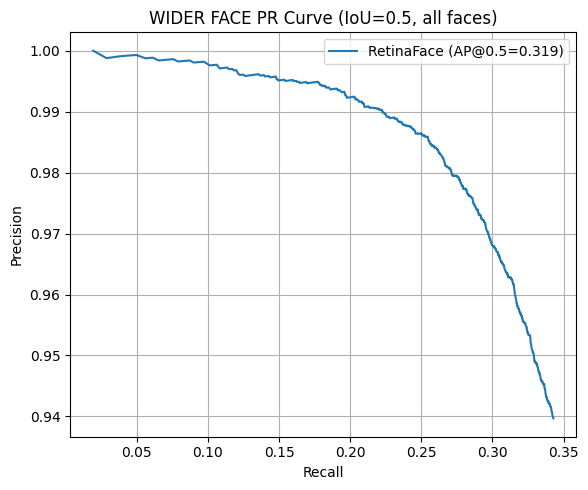

Annotated images saved to: annotated_images/retina_face_widerface_tt


In [ ]:
from datasets import load_dataset

def run_retinaface(ds, batch_size=16, conf=0.001, device=0):

    from batch_face import RetinaFace
    import numpy as np
    from tqdm import tqdm

    det = RetinaFace(gpu_id=device, fp16=True)

    # images = [np.array(sample["image"].convert("RGB")) for sample in ds]
    images = [np.array(sample["image"].convert("RGB"))[:, :, ::-1] for sample in ds]
    all_preds = [None] * len(ds)

    for start in tqdm(range(0, len(ds), batch_size), desc="RetinaFace"):
        end = min(start + batch_size, len(ds))
        batch_imgs = images[start:end]

        results = det(batch_imgs, batch_size=len(batch_imgs), return_dict=True)

        for offset, faces in enumerate(results):
            preds = []
            for f in faces:
                if f["score"] >= conf:
                    x1, y1, x2, y2 = f["box"]
                    preds.append([x1, y1, x2-x1, y2-y1, float(f["score"])])

            if len(preds) == 0:
                all_preds[start + offset] = np.zeros((0, 5))
            else:
                p = np.array(preds)
                all_preds[start + offset] = p[np.argsort(-p[:, 4])]

    return all_preds

# COCO-style IoU thresholds for mAP
iou_thresholds = np.arange(0.50, 0.96, 0.05).tolist()
save_dir = "annotated_images/retina_face_widerface_tt"
wider_face_dataset = load_dataset("CUHK-CSE/wider_face", split="validation", trust_remote_code=True)
retinaface_metrics = evaluate_model(wider_face_dataset, run_retinaface, "RetinaFace", iou_thresholds, plot_pr=True, output_dir=save_dir, save_plots = True, small_max=20, medium_max=50)
print(f"Annotated images saved to: {save_dir}")

## SCRFD

Running SCRFD inference...
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\User/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'],

SCRFD: 100%|██████████| 3226/3226 [1:06:24<00:00,  1.24s/it]


Saving bounding box visualizations to: annotated_images/scrfd_widerface
Preparing data structures and size buckets...
Normalizing scores (global)...

[1] Official-style AP@0.5 on all faces


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [11:41<00:00,  4.60it/s]


AP@0.50 (all faces): 0.8439

[2] COCO-style mAP@0.50:0.95 (all faces)


Evaluating IoU=0.95: 100%|██████████| 3226/3226 [12:33<00:00,  4.28it/s]


mAP@0.50:0.95 (all faces): 0.4782

[3] AP@0.5 by face size buckets


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [12:30<00:00,  4.30it/s]


AP@0.50 (small faces) : 0.6142
AP@0.50 (medium faces): 0.8840
AP@0.50 (large faces) : 0.9539

Official-style AP@0.50 (all faces) : 0.8439
mAP@0.50:0.95 (all faces)     : 0.4782
AP@0.50 (small faces)              : 0.6142
AP@0.50 (medium faces)             : 0.8840
AP@0.50 (large faces)              : 0.9539


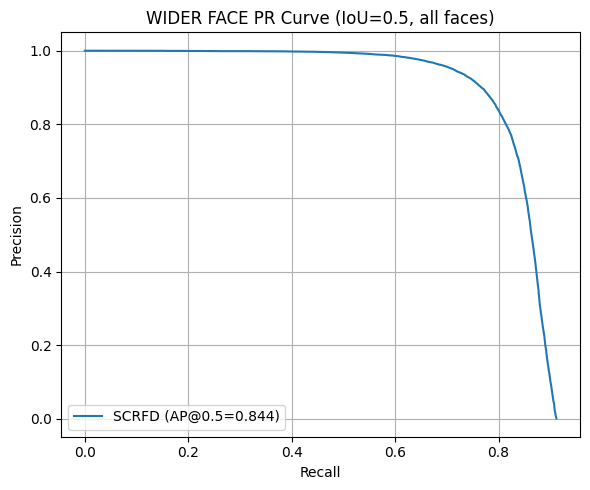

Annotated images saved to: annotated_images/scrfd_widerface


In [ ]:
from datasets import load_dataset

def run_scrfd(ds, conf=0.001, device=0):

    from insightface.app import FaceAnalysis
    import numpy as np
    from tqdm import tqdm

    app = FaceAnalysis(allowed_modules=["detection"])
    app.prepare(ctx_id=device, det_thresh=conf)

    images = [np.array(sample["image"].convert("RGB")) for sample in ds]
    all_preds = [None] * len(ds)

    for i in tqdm(range(len(ds)), desc="SCRFD"):
        faces = app.get(images[i])
        preds = []

        for f in faces:
            if f.det_score >= conf:
                x1, y1, x2, y2 = f.bbox.astype(int)
                preds.append([x1, y1, x2-x1, y2-y1, float(f.det_score)])

        if len(preds) == 0:
            all_preds[i] = np.zeros((0, 5))
        else:
            p = np.array(preds)
            all_preds[i] = p[np.argsort(-p[:, 4])]

    return all_preds

# COCO-style IoU thresholds for mAP
iou_thresholds = np.arange(0.50, 0.96, 0.05).tolist()
save_dir = "annotated_images/scrfd_widerface"
wider_face_dataset = load_dataset("CUHK-CSE/wider_face", split="validation", trust_remote_code=True)
scrfd_metrics = evaluate_model(wider_face_dataset, run_scrfd, "SCRFD", iou_thresholds, plot_pr=True, output_dir=save_dir, save_plots = True, small_max=20, medium_max=50)
print(f"Annotated images saved to: {save_dir}")

## YOLO-Face

Running YOLOv12-face inference...
YOLOv12l summary (fused): 283 layers, 26,339,843 parameters, 0 gradients, 88.5 GFLOPs


YOLOv12: 100%|██████████| 202/202 [2:42:59<00:00, 48.41s/it]   


Saving bounding box visualizations to: annotated_images/yolov12_face_widerface
Preparing data structures and size buckets...
Normalizing scores (global)...

[1] Official-style AP@0.5 on all faces


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [00:16<00:00, 196.65it/s]


AP@0.50 (all faces): 0.9045

[2] COCO-style mAP@0.50:0.95 (all faces)


Evaluating IoU=0.95: 100%|██████████| 3226/3226 [00:15<00:00, 202.26it/s]


mAP@0.50:0.95 (all faces): 0.5564

[3] AP@0.5 by face size buckets


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [00:15<00:00, 203.34it/s]


AP@0.50 (small faces) : 0.7833
AP@0.50 (medium faces): 0.9154
AP@0.50 (large faces) : 0.9477

Official-style AP@0.50 (all faces) : 0.9045
mAP@0.50:0.95 (all faces)     : 0.5564
AP@0.50 (small faces)              : 0.7833
AP@0.50 (medium faces)             : 0.9154
AP@0.50 (large faces)              : 0.9477


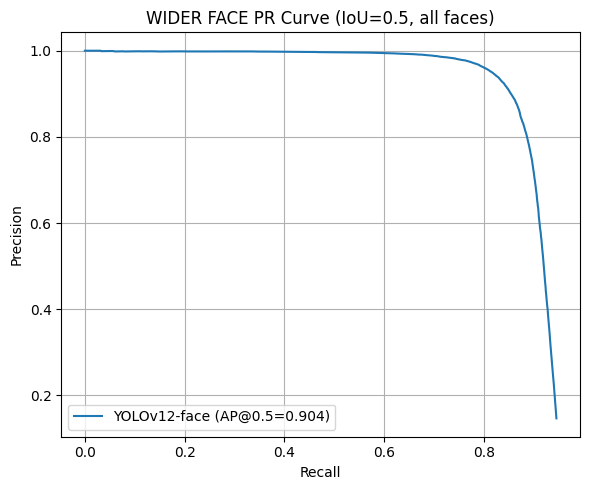

Annotated images saved to: annotated_images/yolov12_face_widerface


In [ ]:
from datasets import load_dataset

def run_yolo(ds, model_path="yolov12l-face.pt", batch_size=16, conf=0.001, img_size=1280, device=0):

    from ultralytics import YOLO
    import numpy as np
    from tqdm import tqdm

    model = YOLO(model_path)
    model.to(device)
    model.fuse()

    all_preds = [None] * len(ds)
    images = [sample["image"] for sample in ds]

    for start in tqdm(range(0, len(ds), batch_size), desc="YOLOv12"):
        end = min(start + batch_size, len(ds))
        batch_imgs = images[start:end]

        results = model(batch_imgs, conf=conf, imgsz=img_size, verbose=False)

        for offset, res in enumerate(results):
            boxes = res.boxes
            if boxes is None or len(boxes) == 0:
                all_preds[start + offset] = np.zeros((0, 5))
                continue

            preds = []
            for b in boxes:
                x1, y1, x2, y2 = b.xyxy[0].cpu().numpy()
                w = x2 - x1
                h = y2 - y1
                score = float(b.conf.item())
                preds.append([x1, y1, w, h, score])

            p = np.array(preds)
            all_preds[start + offset] = p[np.argsort(-p[:, 4])]

    return all_preds

# COCO-style IoU thresholds for mAP
iou_thresholds = np.arange(0.50, 0.96, 0.05).tolist()
save_dir = "annotated_images/yolov12_face_widerface"
wider_face_dataset = load_dataset("CUHK-CSE/wider_face", split="validation", trust_remote_code=True)
yolov12_face_metrics = evaluate_model(wider_face_dataset, run_yolo, "YOLOv12-face", iou_thresholds, plot_pr=True, output_dir=save_dir, save_plots = True, small_max=20, medium_max=50)
print(f"Annotated images saved to: {save_dir}")

## MediaPipe Face Detection

- Does not support Batching

Running MediaPipe inference...


MediaPipe: 100%|██████████| 202/202 [00:25<00:00,  7.82it/s]


Saving bounding box visualizations to: annotated_images/mediapipe_widerface
Preparing data structures and size buckets...
Normalizing scores (global)...

[1] Official-style AP@0.5 on all faces


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [00:05<00:00, 565.11it/s]


AP@0.50 (all faces): 0.1167

[2] COCO-style mAP@0.50:0.95 (all faces)


Evaluating IoU=0.95: 100%|██████████| 3226/3226 [00:05<00:00, 590.75it/s]


mAP@0.50:0.95 (all faces): 0.0400

[3] AP@0.5 by face size buckets


Evaluating IoU=0.50: 100%|██████████| 3226/3226 [00:05<00:00, 595.44it/s]

AP@0.50 (small faces) : 0.0000
AP@0.50 (medium faces): 0.0154
AP@0.50 (large faces) : 0.4965

Official-style AP@0.50 (all faces) : 0.1167
mAP@0.50:0.95 (all faces)     : 0.0400
AP@0.50 (small faces)              : 0.0000
AP@0.50 (medium faces)             : 0.0154
AP@0.50 (large faces)              : 0.4965


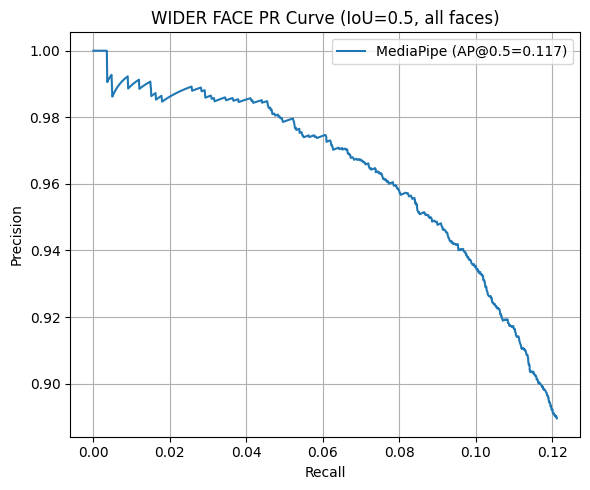

Annotated images saved to: annotated_images/mediapipe_widerface


In [ ]:
from datasets import load_dataset

def run_mediapipe(ds, conf=0.001, batch_size=16):

    import mediapipe as mp
    import numpy as np
    from tqdm import tqdm

    mp_face = mp.solutions.face_detection.FaceDetection(
        model_selection=1,
        min_detection_confidence=conf
    )

    images = [np.array(sample["image"].convert("RGB")) for sample in ds]
    all_preds = [None] * len(ds)

    for start in tqdm(range(0, len(ds), batch_size), desc="MediaPipe"):
        end = min(start + batch_size, len(ds))
        batch_imgs = images[start:end]

        for offset, img in enumerate(batch_imgs):
            h, w, _ = img.shape
            res = mp_face.process(img)

            preds = []
            if res.detections:
                for det in res.detections:
                    bb = det.location_data.relative_bounding_box
                    x1 = int(bb.xmin * w)
                    y1 = int(bb.ymin * h)
                    x2 = int((bb.xmin + bb.width) * w)
                    y2 = int((bb.ymin + bb.height) * h)
                    score = float(det.score[0])
                    preds.append([x1, y1, x2-x1, y2-y1, score])

            if len(preds) == 0:
                all_preds[start + offset] = np.zeros((0, 5))
            else:
                p = np.array(preds)
                all_preds[start + offset] = p[np.argsort(-p[:, 4])]

    return all_preds

# COCO-style IoU thresholds for mAP
iou_thresholds = np.arange(0.50, 0.96, 0.05).tolist()
save_dir = "annotated_images/mediapipe_widerface"
wider_face_dataset = load_dataset("CUHK-CSE/wider_face", split="validation", trust_remote_code=True)
mediapipe_metrics = evaluate_model(wider_face_dataset, run_mediapipe, "MediaPipe", iou_thresholds, plot_pr=True, output_dir=save_dir, save_plots = True, small_max=20, medium_max=50)
print(f"Annotated images saved to: {save_dir}")